<a href="https://colab.research.google.com/github/Geethika1205/Generative_AI_2025/blob/main/Unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving combined_dataset (1).zip to combined_dataset (1).zip


In [3]:
from zipfile import ZipFile
import os

# Upload your ZIP file (already done)
zip_path = '/content/combined_dataset (1).zip'

# Extract it
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

# Check extracted folder structure
os.listdir("/content/data")


['frame_00834.jpg',
 'frame_00120.jpg',
 'frame_01026.jpg',
 'frame_01764.jpg',
 'frame_01824.jpg',
 'frame_01476.jpg',
 'frame_01296.jpg',
 'frame_01884.jpg',
 'frame_01524.jpg',
 'frame_01104.jpg',
 'frame_01338.jpg',
 'frame_01548.jpg',
 'frame_00684.jpg',
 'frame_01608.jpg',
 'frame_01722.jpg',
 'frame_00438.jpg',
 'frame_00432.jpg',
 'frame_00006.jpg',
 'frame_00522.jpg',
 'frame_01086.jpg',
 'frame_01812.jpg',
 'frame_00570.jpg',
 'frame_00876.jpg',
 'frame_00348.jpg',
 'frame_01314.jpg',
 'frame_00678.jpg',
 'frame_01530.jpg',
 'frame_01428.jpg',
 'frame_00186.jpg',
 'frame_00696.jpg',
 'frame_00588.jpg',
 'frame_01176.jpg',
 'frame_01386.jpg',
 'frame_01356.jpg',
 'frame_00378.jpg',
 'frame_01284.jpg',
 'frame_01668.jpg',
 'frame_00732.jpg',
 'frame_00930.jpg',
 'frame_01818.jpg',
 'frame_01326.jpg',
 'frame_01596.jpg',
 'frame_00030.jpg',
 'frame_01614.jpg',
 'frame_01728.jpg',
 'frame_01128.jpg',
 'frame_01662.jpg',
 'frame_00462.jpg',
 'frame_01482.jpg',
 'frame_00606.jpg',


In [4]:
import cv2
import numpy as np
import os
from tqdm import tqdm

input_images = []
target_masks = []

folder_path = "/content/data"
image_size = 128  # You can change this

for filename in tqdm(os.listdir(folder_path)):
    if filename.endswith('.jpg') or filename.endswith('.png'):
        path = os.path.join(folder_path, filename)
        img = cv2.imread(path)
        img = cv2.resize(img, (image_size*2, image_size))

        input_img = img[:, :image_size]
        target_img = img[:, image_size:]

        input_images.append(input_img / 255.0)
        target_masks.append(target_img / 255.0)

X = np.array(input_images)
Y = np.array(target_masks)

print("Input shape:", X.shape)
print("Target shape:", Y.shape)


100%|██████████| 335/335 [00:01<00:00, 273.08it/s]


Input shape: (334, 128, 128, 3)
Target shape: (334, 128, 128, 3)


In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate

def unet_model(input_size=(128, 128, 3)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D(pool_size=(2, 2))(c1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D(pool_size=(2, 2))(c2)

    # Bottleneck
    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)

    # Decoder
    u4 = UpSampling2D(size=(2, 2))(c3)
    u4 = concatenate([u4, c2])
    c4 = Conv2D(128, 3, activation='relu', padding='same')(u4)
    c4 = Conv2D(128, 3, activation='relu', padding='same')(c4)

    u5 = UpSampling2D(size=(2, 2))(c4)
    u5 = concatenate([u5, c1])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u5)
    c5 = Conv2D(64, 3, activation='relu', padding='same')(c5)

    outputs = Conv2D(3, 1, activation='sigmoid')(c5)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


In [6]:
from tensorflow.keras.optimizers import Adam

model = unet_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X, Y, epochs=25, batch_size=8, validation_split=0.1)


Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.4165 - loss: 0.6728

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 486ms/step - accuracy: 0.4170 - loss: 0.6723 - val_accuracy: 0.4554 - val_loss: 0.6130
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.4536 - loss: 0.6069 - val_accuracy: 0.5134 - val_loss: 0.5970
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.4688 - loss: 0.5940 - val_accuracy: 0.4923 - val_loss: 0.5896
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.4879 - loss: 0.5876 - val_accuracy: 0.5052 - val_loss: 0.5912
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.4961 - loss: 0.5832 - val_accuracy: 0.6023 - val_loss: 0.5813
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.5615 - loss: 0.5789 - val_accuracy: 0.6408 - val_loss: 0.5700
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.6264 - loss: 0.5697 - val_accuracy: 0.6105 - val_loss: 0.5692
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6278 - loss: 0.5629 - val_accuracy: 0.6279 - val_loss: 

In [7]:
model.save("unet_lane_detection_model.h5")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


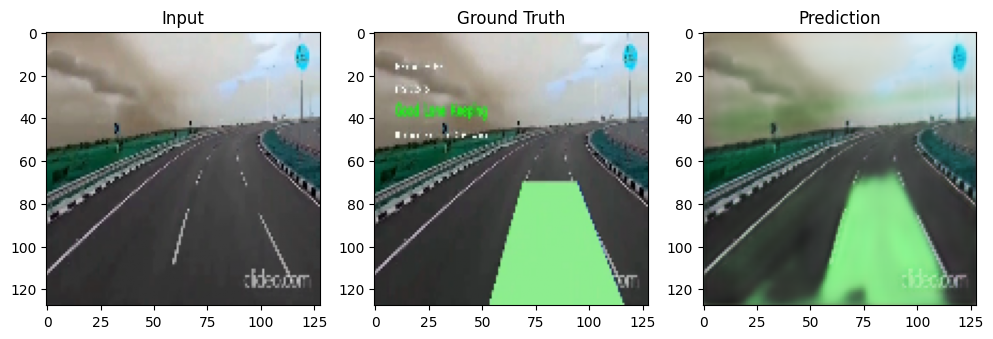

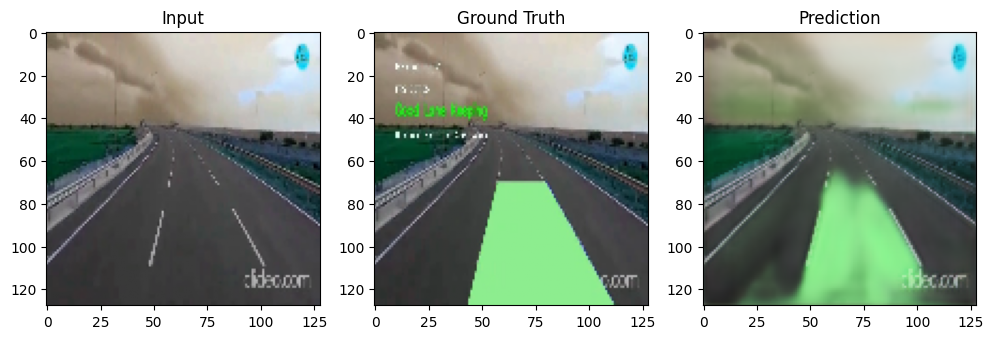

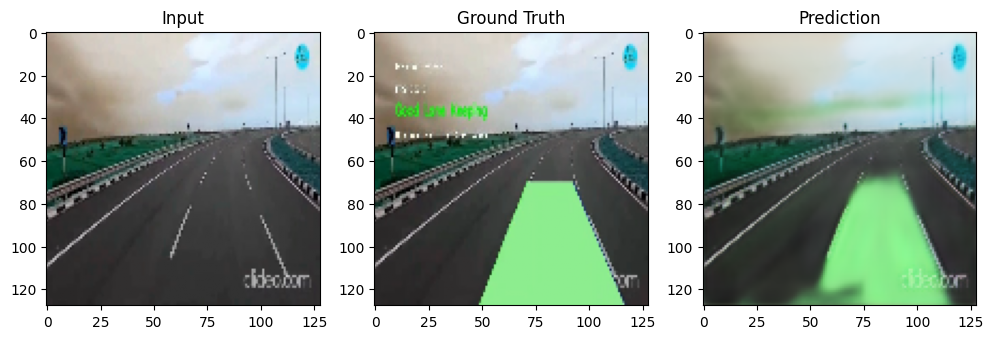

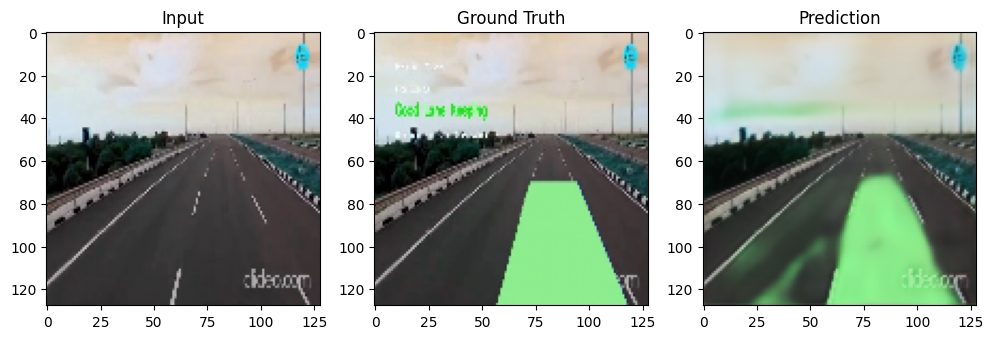

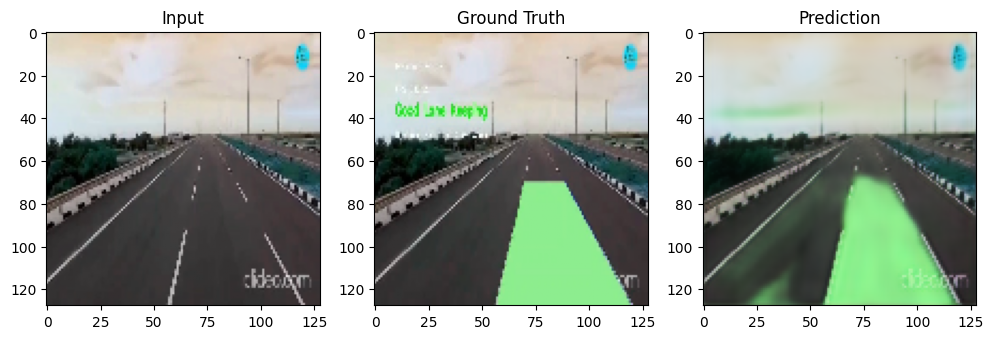

In [8]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load the trained model
model = load_model("/content/unet_lane_detection_model.h5")

# Predict on first 5 images
preds = model.predict(X[:5])

# Plot input, target and prediction
for i in range(5):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Input")
    plt.imshow(X[i])

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(Y[i])

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(preds[i])

    plt.show()


In [9]:
loss, accuracy = model.evaluate(X, Y)
print(f"Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 521ms/step - accuracy: 0.6250 - loss: 0.5418
Loss: 0.5427, Accuracy: 0.6247


In [14]:
# ✅ STEP 1: IMPORT LIBRARIES
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt


In [15]:
# ✅ STEP 2: LOAD & PREPROCESS DATA
folder_path = "/content/data"   # Make sure your extracted dataset is here
image_size = 128
input_images, target_masks = [], []

for filename in tqdm(os.listdir(folder_path)):
    if filename.endswith('.jpg') or filename.endswith('.png'):
        path = os.path.join(folder_path, filename)
        img = cv2.imread(path)
        img = cv2.resize(img, (image_size * 2, image_size))  # Combine input & target
        input_img = img[:, :image_size] / 255.0
        target_img = img[:, image_size:] / 255.0

        input_images.append(input_img)
        target_masks.append(target_img)

X = np.array(input_images, dtype=np.float32)
Y = np.array(target_masks, dtype=np.float32)

print("Input shape:", X.shape)
print("Target shape:", Y.shape)


100%|██████████| 335/335 [00:01<00:00, 258.28it/s]

Input shape: (334, 128, 128, 3)
Target shape: (334, 128, 128, 3)


In [16]:
# ✅ STEP 3: DEFINE LOSS & METRICS

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def iou_metric(y_true, y_pred):
    y_pred = K.cast(y_pred > 0.5, 'float32')
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return intersection / (union + K.epsilon())


In [17]:
# ✅ STEP 4: DEFINE U-NET MODEL

def unet_model(input_size=(128, 128, 3)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)

    # Decoder
    u4 = UpSampling2D((2, 2))(c3)
    u4 = concatenate([u4, c2])
    c4 = Conv2D(128, 3, activation='relu', padding='same')(u4)
    c4 = Conv2D(128, 3, activation='relu', padding='same')(c4)

    u5 = UpSampling2D((2, 2))(c4)
    u5 = concatenate([u5, c1])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u5)
    c5 = Conv2D(64, 3, activation='relu', padding='same')(c5)

    outputs = Conv2D(3, 1, activation='sigmoid')(c5)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


In [18]:
# ✅ STEP 5: DATA AUGMENTATION + CALLBACKS

datagen = ImageDataGenerator(
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.1
)

train_gen = datagen.flow(X, Y, batch_size=8, subset='training')
val_gen = datagen.flow(X, Y, batch_size=8, subset='validation')

callbacks = [
    ModelCheckpoint("/content/unet_lane_detection_model.h5", save_best_only=True),
    EarlyStopping(patience=8, restore_best_weights=True)
]


In [19]:
# ✅ STEP 6: COMPILE AND TRAIN THE MODEL

model = unet_model()
model.compile(optimizer=Adam(1e-4), loss=dice_loss, metrics=['accuracy', iou_metric])

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen),
    callbacks=callbacks
)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_72']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_72']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.2064 - iou_metric: 0.4443 - loss: 0.4520

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_72']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 447ms/step - accuracy: 0.2084 - iou_metric: 0.4454 - loss: 0.4505 - val_accuracy: 0.4005 - val_iou_metric: 0.5177 - val_loss: 0.3287
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3953 - iou_metric: 0.5051 - loss: 0.3293

...

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.5377 - iou_metric: 0.5340 - loss: 0.3040 - val_accuracy: 0.5271 - val_iou_metric: 0.5439 - val_loss: 0.3009
Epoch 24/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.5029 - iou_metric: 0.5371 - loss: 0.3015 - val_accuracy: 0.5304 - val_iou_metric: 0.5356 - val_loss: 0.3036
Epoch 25/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.5419 - iou_metric: 0.5335 - loss: 0.3045 - val_accuracy: 0.5221 - val_iou_metric: 0.5384 - val_loss: 0.3033
Epoch 26/50
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5401 - iou_metric: 0.5349 - loss: 0.3032

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5400 - iou_metric: 0.5349 - loss: 0.3032 - val_accuracy: 0.5329 - val_iou_metric: 0.5323 - val_loss: 0.3007
Epoch 27/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5390 - iou_metric: 0.5309 - loss: 0.3062

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.5390 - iou_metric: 0.5310 - loss: 0.3062 - val_accuracy: 0.5096 - val_iou_metric: 0.5578 - val_loss: 0.2983
Epoch 28/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.5410 - iou_metric: 0.5353 - loss: 0.3031 - val_accuracy: 0.5296 - val_iou_metric: 0.5305 - val_loss: 0.3020
Epoch 29/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.5367 - iou_metric: 0.5314 - loss: 0.3065 - val_accuracy: 0.5250 - val_iou_metric: 0.5399 - val_loss: 0.3021
Epoch 30/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.5399 - iou_metric: 0.5361 - loss: 0.3028 - val_accuracy: 0.5328 - val_iou_metric: 0.5468 - val_loss: 0.2986
Epoch 31/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.5516 - iou_metric: 0.5332 - loss: 0.3048 - val_accuracy: 0.5302 - val_iou_metric: 0.5180 - val_loss: 0.3010
Epoch 32/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.5336 - iou_metric: 0.5420 - loss: 0.2974 - val_accuracy: 0.5279 - val_iou_me

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5446 - iou_metric: 0.5368 - loss: 0.3016 - val_accuracy: 0.5234 - val_iou_metric: 0.5303 - val_loss: 0.2979
Epoch 35/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.5380 - iou_metric: 0.5389 - loss: 0.2999 - val_accuracy: 0.5343 - val_iou_metric: 0.5452 - val_loss: 0.3004
Epoch 36/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5399 - iou_metric: 0.5388 - loss: 0.2994

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.5399 - iou_metric: 0.5388 - loss: 0.2994 - val_accuracy: 0.5183 - val_iou_metric: 0.5383 - val_loss: 0.2941
Epoch 37/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.5250 - iou_metric: 0.5380 - loss: 0.3006 - val_accuracy: 0.5312 - val_iou_metric: 0.5428 - val_loss: 0.2975
Epoch 38/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.5502 - iou_metric: 0.5381 - loss: 0.3005 - val_accuracy: 0.5356 - val_iou_metric: 0.5482 - val_loss: 0.2942
Epoch 39/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.5446 - iou_metric: 0.5349 - loss: 0.3031 - val_accuracy: 0.4854 - val_iou_metric: 0.5359 - val_loss: 0.2992
Epoch 40/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.5254 - iou_metric: 0.5350 - loss: 0.3033 - val_accuracy: 0.5368 - val_iou_metric: 0.5379 - val_loss: 0.2987
Epoch 41/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.5526 - iou_metric: 0.5349 - loss: 0.3032 - val_accuracy: 0.5338 - val_iou_me

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_72']
Received: inputs=Tensor(shape=(5, 128, 128, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


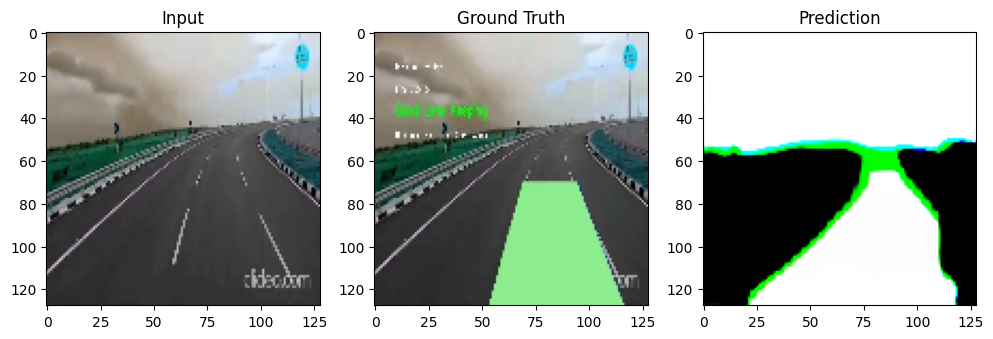

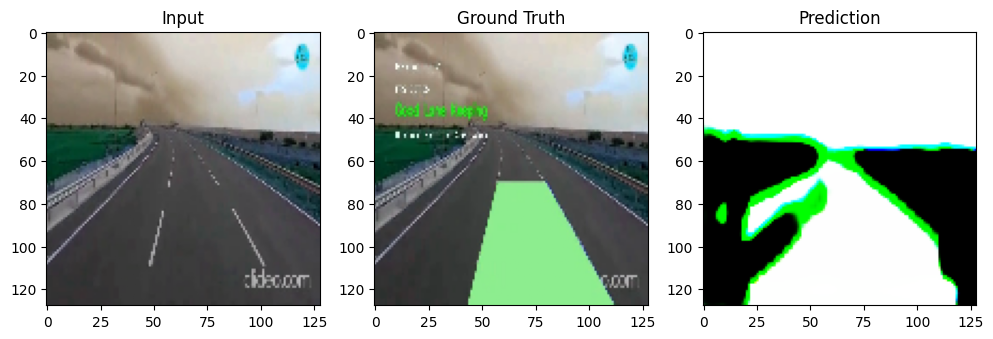

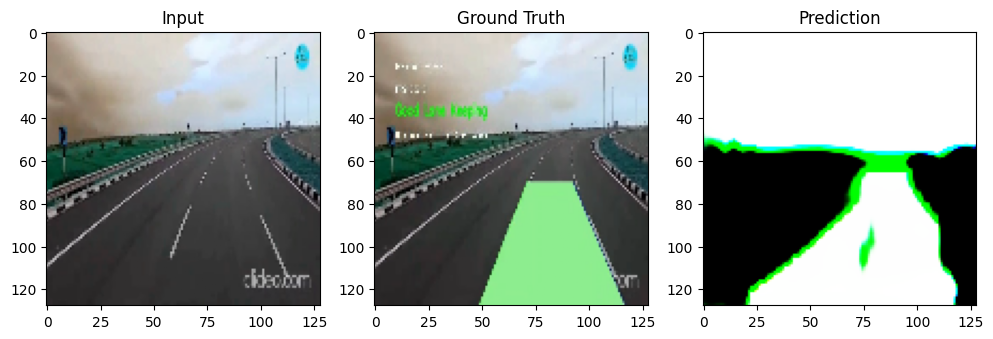

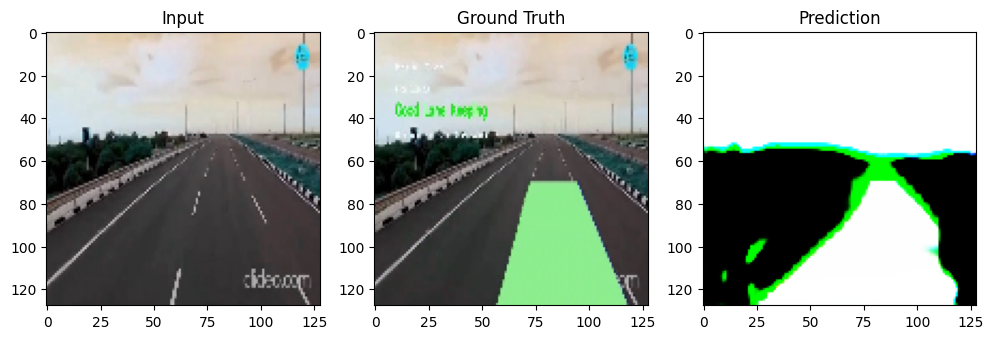

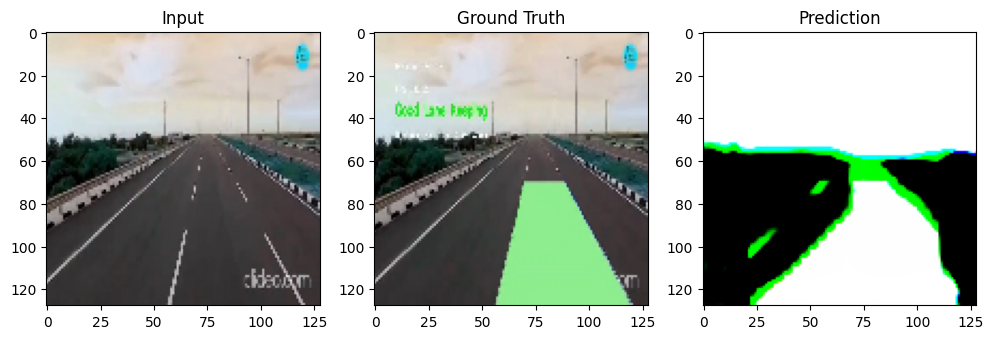

In [20]:
# ✅ STEP 7: VISUALIZE PREDICTIONS

preds = model.predict(X[:5])

for i in range(5):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Input")
    plt.imshow(X[i])

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(Y[i])

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(preds[i])

    plt.show()
